In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random


from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.decomposition import PCA

from sklearn.linear_model import Ridge

from sklearn.feature_selection import RFE


from pycaret.regression import *


def set_seeds(seed=42):
    """
    Sets the seed for reproducibility across Python, NumPy, and TensorFlow.
    """
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    # tf.random.set_seed(seed)
    # For newer versions of TF/Keras to ensure deterministic behavior on GPU if possible
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    print(f"Random seed set to: {seed}")
set_seeds(42)


Random seed set to: 42


# Functions


In [2]:
def working_df(data, gw, features=None):

    GW_full = data['round'].values

    # Split
    GW_TRAIN_END = gw - 1
    train_mask = GW_full <= GW_TRAIN_END
    test_mask = GW_full == (GW_TRAIN_END + 1)

    train_data = data[train_mask]
    test_data = data[test_mask]

    test_player_names = test_data['fpl_name'].values
    test_player_ids = test_data['fpl_id'].values
    # test_player_positions = test_data['position'].values
    test_data = test_data.drop(columns=['fpl_name', 'fpl_id', 'team_id', 'round'])
    train_data = train_data.drop(columns=['fpl_name', 'fpl_id', 'team_id', 'round'])

    return train_data, test_data, test_player_names, test_player_ids, test_mask

def plot_preds(preds, position, gw, full_data, test_mask):
    # xp_actual = test_target
    # xp_pred = preds #['prediction_label'].values
    # position = data_25_26[test_mask]['position'].values

    preds_data = pd.DataFrame({
        'fpl_name': full_data[test_mask]['fpl_name'].values,
        'Actual_xP':  full_data[test_mask]['xP'].values,
        'Pred_xP': preds,
        'position': full_data[test_mask]['position'].values
    })

    position = position
    names = preds_data[preds_data['position'] == position]['fpl_name'].values
    xp_actual = preds_data[preds_data['position'] == position]['Actual_xP'].values
    xp_pred = preds_data[preds_data['position'] == position]['Pred_xP'].values


    # Convert names to positions on x-axis
    x = np.arange(len(names))

    plt.figure(figsize=(14, 6))

    # Plot actual points
    plt.plot(x, xp_actual, marker='o', linewidth=2, label='Actual Points')

    # Plot predicted points
    plt.plot(x, xp_pred, marker='x', linewidth=2, label='Predicted Points')

    # Improve readability
    plt.xticks(x, names, rotation=75, ha='right')
    plt.xlabel("Players")
    plt.ylabel("Points")
    plt.title(f" : Actual vs Predicted Points per Player for position {position} (GW {gw})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Width of each bar
    width = 0.31

    plt.figure(figsize=(14, 6))

    # Bars
    plt.bar(x - width/2, xp_actual, width, label='Actual Points')
    plt.bar(x + width/2, xp_pred, width, label='Predicted Points')

    # Labels & formatting
    plt.xticks(x, names, rotation=75, ha='right')
    plt.xlabel("Players")
    plt.ylabel("Points")
    plt.title(f" {position} : Actual vs Predicted Points per Player for position {position} (GW {gw})")
    plt.legend()

    plt.tight_layout()
    plt.show()


# Data Prep


In [3]:
# data_25_26 = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/Prediction%20with%20Affine%20PNN/data/rolled_player_data.csv')
data_25_26 = pd.read_csv('../Prediction with Affine PNN/data/rolled_player_data.csv')
data_25_26

,fpl_id,round,first_name,second_name,web_name,now_cost,selected_by_percent,form,event_points,transfers_in_event,...,strength_attack_away_5_ewm,strength_defence_home_1_ewm,strength_defence_home_3_ewm,strength_defence_home_5_ewm,strength_defence_away_1_ewm,strength_defence_away_3_ewm,strength_defence_away_5_ewm,opp_clean_sheets,opp_elo,opp_strength
0,1.0,1,David,Raya Martín,Raya,6.0,36.9,3.2,10.0,418466.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
1,1.0,2,David,Raya Martín,Raya,5.5,21.5,8.0,6.0,77335.0,...,1350.0,1290.0,1290.0,1290.0,1300.0,1300.0,1300.0,1.000000,2037.000000,4.000000
2,1.0,3,David,Raya Martín,Raya,5.5,21.8,6.0,2.0,38830.0,...,1350.0,1290.0,1290.0,1290.0,1300.0,1300.0,1300.0,1.000000,1993.000000,5.000000
3,1.0,4,David,Raya Martín,Raya,5.5,23.5,6.0,6.0,33143.0,...,1350.0,1290.0,1290.0,1290.0,1300.0,1300.0,1300.0,1.000000,2037.000000,4.000000
4,1.0,5,David,Raya Martín,Raya,5.5,24.0,4.0,2.0,95889.0,...,1350.0,1290.0,1290.0,1290.0,1300.0,1300.0,1300.0,0.000000,2037.000000,4.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7330,804.0,24,João Victor,de Souza Menezes,Souza,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.078268,1788.454552,3.091083
7331,805.0,24,Lorenzo,Lucca,Lucca,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.441198,1844.337157,3.082125
7332,806.0,24,Christos,Mandas,Mandas,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.394673,1826.743534,3.036766
7333,807.0,24,Rayan Vitor,Simplício Rocha,Rayan,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.394673,1826.743534,3.036766


In [4]:

gw=24

cols = [

    'fpl_id', 'round', 'fpl_name', 'position', 'team_id', 'team', 'opponent_team', 'was_home', 'xP',# 'xP_next',
    'selected_by_percent','value', 'transfers_in', 'transfers_out',  'selected', 'ownership_change', 'percenatge_net_transfers',
    'cbitr_volume_90', 'cbitr_ewm_90', 'cbitr_ewm_probability',  'cbitr_probability','elo',  'team_h_difficulty', 'team_a_difficulty',
    'win_prob', 'draw_prob', 'lose_prob',


    'creativity_rolling_1', 'creativity_rolling_3', 'creativity_rolling_5', 'influence_rolling_1', 'influence_rolling_3', 'influence_rolling_5', 'threat_rolling_1',
    'threat_rolling_3', 'threat_rolling_5', 'minutes_rolling_1', 'minutes_rolling_3', 'minutes_rolling_5', 'pts_bonus_rolling_1', 'pts_bonus_rolling_3',
    'pts_bonus_rolling_5', 'expected_goals_rolling_1', 'expected_goals_rolling_3', 'expected_goals_rolling_5', 'expected_assists_rolling_1',
    'expected_assists_rolling_3', 'expected_assists_rolling_5', 'xP_rolling_1', 'xP_rolling_3', 'xP_rolling_5', 'expected_goals_conceded_rolling_1',
    'expected_goals_conceded_rolling_3', 'expected_goals_conceded_rolling_5', 'goals_conceded_rolling_1', 'goals_conceded_rolling_3', 'goals_conceded_rolling_5',
    'goals_scored_rolling_1', 'goals_scored_rolling_3', 'goals_scored_rolling_5', 'shots_rolling_1', 'shots_rolling_3', 'shots_rolling_5', 'key_passes_rolling_1',
    'key_passes_rolling_3', 'key_passes_rolling_5', 'npg_rolling_1', 'npg_rolling_3', 'npg_rolling_5', 'npxG_rolling_1', 'npxG_rolling_3', 'npxG_rolling_5',
    'goals_rolling_1', 'goals_rolling_3', 'goals_rolling_5', 'xG_rolling_1', 'xG_rolling_3', 'xG_rolling_5', 'xA_rolling_1', 'xA_rolling_3', 'xA_rolling_5',
    'saves_rolling_1', 'saves_rolling_3', 'saves_rolling_5', 'starts_rolling_1', 'starts_rolling_3', 'starts_rolling_5', 'yellow_cards_rolling_1',
    'yellow_cards_rolling_3', 'yellow_cards_rolling_5', 'red_cards_rolling_1', 'red_cards_rolling_3', 'red_cards_rolling_5', 'assists_rolling_1', 'assists_rolling_3',
    'assists_rolling_5', 'clean_sheets_rolling_1', 'clean_sheets_rolling_3', 'clean_sheets_rolling_5', 'value_rolling_1', 'value_rolling_3', 'value_rolling_5',
    'ict_index_rolling_1', 'ict_index_rolling_3', 'ict_index_rolling_5', 'selected_rolling_1', 'selected_rolling_3', 'selected_rolling_5', 'transfers_in_rolling_1',
    'transfers_in_rolling_3', 'transfers_in_rolling_5', 'transfers_out_rolling_1', 'transfers_out_rolling_3', 'transfers_out_rolling_5', 'ownership_change_rolling_1',
    'ownership_change_rolling_3', 'ownership_change_rolling_5', 'percenatge_net_transfers_rolling_1', 'percenatge_net_transfers_rolling_3',
    'percenatge_net_transfers_rolling_5', 'xGChain_rolling_1', 'xGChain_rolling_3', 'xGChain_rolling_5', 'xGBuildup_rolling_1', 'xGBuildup_rolling_3',
    'xGBuildup_rolling_5', 'expected_goal_involvements_rolling_1', 'expected_goal_involvements_rolling_3', 'expected_goal_involvements_rolling_5', 'form_rolling_1',
    'form_rolling_3', 'form_rolling_5', 'clearances_blocks_interceptions_rolling_1', 'clearances_blocks_interceptions_rolling_3',
    'clearances_blocks_interceptions_rolling_5', 'tackles_rolling_1', 'tackles_rolling_3', 'tackles_rolling_5', 'recoveries_rolling_1', 'recoveries_rolling_3',
    'recoveries_rolling_5', 'selected_by_percent_rolling_1', 'selected_by_percent_rolling_3', 'selected_by_percent_rolling_5', 'strength_rolling_1',
    'strength_rolling_3', 'strength_rolling_5', 'strength_overall_home_rolling_1', 'strength_overall_home_rolling_3', 'strength_overall_home_rolling_5',
    'strength_overall_away_rolling_1', 'strength_overall_away_rolling_3', 'strength_overall_away_rolling_5', 'strength_attack_home_rolling_1',
    'strength_attack_home_rolling_3', 'strength_attack_home_rolling_5', 'strength_attack_away_rolling_1', 'strength_attack_away_rolling_3',
    'strength_attack_away_rolling_5', 'strength_defence_home_rolling_1', 'strength_defence_home_rolling_3', 'strength_defence_home_rolling_5',
    'strength_defence_away_rolling_1', 'strength_defence_away_rolling_3', 'strength_defence_away_rolling_5',

    'creativity_1_ewm', 'creativity_3_ewm', 'creativity_5_ewm', 'influence_1_ewm', 'influence_3_ewm', 'influence_5_ewm', 'threat_1_ewm', 'threat_3_ewm', 'threat_5_ewm',
    'minutes_1_ewm', 'minutes_3_ewm', 'minutes_5_ewm', 'pts_bonus_1_ewm', 'pts_bonus_3_ewm', 'pts_bonus_5_ewm', 'expected_goals_1_ewm', 'expected_goals_3_ewm',
    'expected_goals_5_ewm', 'expected_assists_1_ewm', 'expected_assists_3_ewm', 'expected_assists_5_ewm', 'xP_1_ewm', 'xP_3_ewm', 'xP_5_ewm',
    'expected_goals_conceded_1_ewm', 'expected_goals_conceded_3_ewm', 'expected_goals_conceded_5_ewm', 'goals_conceded_1_ewm', 'goals_conceded_3_ewm',
    'goals_conceded_5_ewm', 'goals_scored_1_ewm', 'goals_scored_3_ewm', 'goals_scored_5_ewm', 'shots_1_ewm', 'shots_3_ewm', 'shots_5_ewm', 'key_passes_1_ewm',
    'key_passes_3_ewm', 'key_passes_5_ewm', 'npg_1_ewm', 'npg_3_ewm', 'npg_5_ewm', 'npxG_1_ewm', 'npxG_3_ewm', 'npxG_5_ewm', 'goals_1_ewm', 'goals_3_ewm',
    'goals_5_ewm', 'xG_1_ewm', 'xG_3_ewm', 'xG_5_ewm', 'xA_1_ewm', 'xA_3_ewm', 'xA_5_ewm', 'saves_1_ewm', 'saves_3_ewm', 'saves_5_ewm', 'starts_1_ewm', 'starts_3_ewm',
    'starts_5_ewm', 'yellow_cards_1_ewm', 'yellow_cards_3_ewm', 'yellow_cards_5_ewm', 'red_cards_1_ewm', 'red_cards_3_ewm', 'red_cards_5_ewm', 'assists_1_ewm',
    'assists_3_ewm', 'assists_5_ewm', 'clean_sheets_1_ewm', 'clean_sheets_3_ewm', 'clean_sheets_5_ewm', 'value_1_ewm', 'value_3_ewm', 'value_5_ewm', 'ict_index_1_ewm',
    'ict_index_3_ewm', 'ict_index_5_ewm', 'selected_1_ewm', 'selected_3_ewm', 'selected_5_ewm', 'transfers_in_1_ewm', 'transfers_in_3_ewm', 'transfers_in_5_ewm',
    'transfers_out_1_ewm', 'transfers_out_3_ewm', 'transfers_out_5_ewm', 'ownership_change_1_ewm', 'ownership_change_3_ewm', 'ownership_change_5_ewm',
    'percenatge_net_transfers_1_ewm', 'percenatge_net_transfers_3_ewm', 'percenatge_net_transfers_5_ewm', 'xGChain_1_ewm', 'xGChain_3_ewm', 'xGChain_5_ewm',
    'xGBuildup_1_ewm', 'xGBuildup_3_ewm', 'xGBuildup_5_ewm', 'expected_goal_involvements_1_ewm', 'expected_goal_involvements_3_ewm', 'expected_goal_involvements_5_ewm',
    'form_1_ewm', 'form_3_ewm', 'form_5_ewm', 'clearances_blocks_interceptions_1_ewm', 'clearances_blocks_interceptions_3_ewm', 'clearances_blocks_interceptions_5_ewm',
    'tackles_1_ewm', 'tackles_3_ewm', 'tackles_5_ewm', 'recoveries_1_ewm', 'recoveries_3_ewm', 'recoveries_5_ewm', 'selected_by_percent_1_ewm',
    'selected_by_percent_3_ewm', 'selected_by_percent_5_ewm', 'strength_1_ewm', 'strength_3_ewm', 'strength_5_ewm', 'strength_overall_home_1_ewm',
    'strength_overall_home_3_ewm', 'strength_overall_home_5_ewm', 'strength_overall_away_1_ewm', 'strength_overall_away_3_ewm', 'strength_overall_away_5_ewm',
    'strength_attack_home_1_ewm', 'strength_attack_home_3_ewm', 'strength_attack_home_5_ewm', 'strength_attack_away_1_ewm', 'strength_attack_away_3_ewm',
    'strength_attack_away_5_ewm', 'strength_defence_home_1_ewm', 'strength_defence_home_3_ewm', 'strength_defence_home_5_ewm', 'strength_defence_away_1_ewm',
    'strength_defence_away_3_ewm', 'strength_defence_away_5_ewm',

    'opp_elo', 'opp_clean_sheets', 'opp_strength'
    ]

data_25_26 = data_25_26.rename({'web_name': 'fpl_name'}, axis=1)

hist_data = data_25_26[
    (data_25_26['round'] > 5)  &
    (data_25_26['minutes_rolling_3'] > 15) &
    (data_25_26['minutes'] > 15)
    ]
tar_data = data_25_26[(data_25_26['round'] == gw) & (data_25_26['minutes_rolling_3'] >= 15)]

data_25_26_ = pd.concat([hist_data, tar_data])

active_data = data_25_26_[cols].copy()
active_data_ = active_data.copy()

CATEGORICAL_COLS = ['position', 'team', 'opponent_team']

# Initialize encoder
# handle_unknown='ignore' ensures new teams result in all-zero rows for those features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical columns
encoded_array = encoder.fit(active_data_[CATEGORICAL_COLS])

# Create a DataFrame with the encoded features
encoded_cols = encoder.get_feature_names_out(CATEGORICAL_COLS)
encoded_df = pd.DataFrame(
    encoder.transform(active_data_[CATEGORICAL_COLS]),
    columns=encoded_cols,
    index=active_data_.index
)

cols = [*cols, *encoded_cols]
# Combine with numerical data
data = pd.concat([active_data_, encoded_df], axis=1).drop(columns=CATEGORICAL_COLS)

feature_cols = [
    # 'xP_next',
 'selected_by_percent',
 'value',
 'transfers_in',
 'transfers_out',
 'selected',
 'ownership_change',
 'percenatge_net_transfers',
 'cbitr_volume_90',
 'cbitr_ewm_90',
 'cbitr_ewm_probability',
 'cbitr_probability',
 'elo',
 'team_h_difficulty',
 'team_a_difficulty',
 'win_prob',
 'draw_prob',
 'lose_prob',
 'creativity_rolling_1',
 'creativity_rolling_3',
 'creativity_rolling_5',
 'influence_rolling_1',
 'influence_rolling_3',
 'influence_rolling_5',
 'threat_rolling_1',
 'threat_rolling_3',
 'threat_rolling_5',
 'minutes_rolling_1',
 'minutes_rolling_3',
 'minutes_rolling_5',
 'pts_bonus_rolling_1',
 'pts_bonus_rolling_3',
 'pts_bonus_rolling_5',
 'expected_goals_rolling_1',
 'expected_goals_rolling_3',
 'expected_goals_rolling_5',
 'expected_assists_rolling_1',
 'expected_assists_rolling_3',
 'expected_assists_rolling_5',
 'xP_rolling_1',
 'xP_rolling_3',
 'xP_rolling_5',
 'expected_goals_conceded_rolling_1',
 'expected_goals_conceded_rolling_3',
 'expected_goals_conceded_rolling_5',
 'goals_conceded_rolling_1',
 'goals_conceded_rolling_3',
 'goals_conceded_rolling_5',
 'goals_scored_rolling_1',
 'goals_scored_rolling_3',
 'goals_scored_rolling_5',
 'shots_rolling_1',
 'shots_rolling_3',
 'shots_rolling_5',
 'key_passes_rolling_1',
 'key_passes_rolling_3',
 'key_passes_rolling_5',
 'npg_rolling_1',
 'npg_rolling_3',
 'npg_rolling_5',
 'npxG_rolling_1',
 'npxG_rolling_3',
 'npxG_rolling_5',
 'goals_rolling_1',
 'goals_rolling_3',
 'goals_rolling_5',
 'xG_rolling_1',
 'xG_rolling_3',
 'xG_rolling_5',
 'xA_rolling_1',
 'xA_rolling_3',
 'xA_rolling_5',
 'saves_rolling_1',
 'saves_rolling_3',
 'saves_rolling_5',
 'starts_rolling_1',
 'starts_rolling_3',
 'starts_rolling_5',
 'yellow_cards_rolling_1',
 'yellow_cards_rolling_3',
 'yellow_cards_rolling_5',
 'red_cards_rolling_1',
 'red_cards_rolling_3',
 'red_cards_rolling_5',
 'assists_rolling_1',
 'assists_rolling_3',
 'assists_rolling_5',
 'clean_sheets_rolling_1',
 'clean_sheets_rolling_3',
 'clean_sheets_rolling_5',
 'value_rolling_1',
 'value_rolling_3',
 'value_rolling_5',
 'ict_index_rolling_1',
 'ict_index_rolling_3',
 'ict_index_rolling_5',
 'selected_rolling_1',
 'selected_rolling_3',
 'selected_rolling_5',
 'transfers_in_rolling_1',
 'transfers_in_rolling_3',
 'transfers_in_rolling_5',
 'transfers_out_rolling_1',
 'transfers_out_rolling_3',
 'transfers_out_rolling_5',
 'ownership_change_rolling_1',
 'ownership_change_rolling_3',
 'ownership_change_rolling_5',
 'percenatge_net_transfers_rolling_1',
 'percenatge_net_transfers_rolling_3',
 'percenatge_net_transfers_rolling_5',
 'xGChain_rolling_1',
 'xGChain_rolling_3',
 'xGChain_rolling_5',
 'xGBuildup_rolling_1',
 'xGBuildup_rolling_3',
 'xGBuildup_rolling_5',
 'expected_goal_involvements_rolling_1',
 'expected_goal_involvements_rolling_3',
 'expected_goal_involvements_rolling_5',
 'form_rolling_1',
 'form_rolling_3',
 'form_rolling_5',
 'clearances_blocks_interceptions_rolling_1',
 'clearances_blocks_interceptions_rolling_3',
 'clearances_blocks_interceptions_rolling_5',
 'tackles_rolling_1',
 'tackles_rolling_3',
 'tackles_rolling_5',
 'recoveries_rolling_1',
 'recoveries_rolling_3',
 'recoveries_rolling_5',
 'selected_by_percent_rolling_1',
 'selected_by_percent_rolling_3',
 'selected_by_percent_rolling_5',
 'strength_rolling_1',
 'strength_rolling_3',
 'strength_rolling_5',
 'strength_overall_home_rolling_1',
 'strength_overall_home_rolling_3',
 'strength_overall_home_rolling_5',
 'strength_overall_away_rolling_1',
 'strength_overall_away_rolling_3',
 'strength_overall_away_rolling_5',
 'strength_attack_home_rolling_1',
 'strength_attack_home_rolling_3',
 'strength_attack_home_rolling_5',
 'strength_attack_away_rolling_1',
 'strength_attack_away_rolling_3',
 'strength_attack_away_rolling_5',
 'strength_defence_home_rolling_1',
 'strength_defence_home_rolling_3',
 'strength_defence_home_rolling_5',
 'strength_defence_away_rolling_1',
 'strength_defence_away_rolling_3',
 'strength_defence_away_rolling_5',
 'creativity_1_ewm',
 'creativity_3_ewm',
 'creativity_5_ewm',
 'influence_1_ewm',
 'influence_3_ewm',
 'influence_5_ewm',
 'threat_1_ewm',
 'threat_3_ewm',
 'threat_5_ewm',
 'minutes_1_ewm',
 'minutes_3_ewm',
 'minutes_5_ewm',
 'pts_bonus_1_ewm',
 'pts_bonus_3_ewm',
 'pts_bonus_5_ewm',
 'expected_goals_1_ewm',
 'expected_goals_3_ewm',
 'expected_goals_5_ewm',
 'expected_assists_1_ewm',
 'expected_assists_3_ewm',
 'expected_assists_5_ewm',
 'xP_1_ewm',
 'xP_3_ewm',
 'xP_5_ewm',
 'expected_goals_conceded_1_ewm',
 'expected_goals_conceded_3_ewm',
 'expected_goals_conceded_5_ewm',
 'goals_conceded_1_ewm',
 'goals_conceded_3_ewm',
 'goals_conceded_5_ewm',
 'goals_scored_1_ewm',
 'goals_scored_3_ewm',
 'goals_scored_5_ewm',
 'shots_1_ewm',
 'shots_3_ewm',
 'shots_5_ewm',
 'key_passes_1_ewm',
 'key_passes_3_ewm',
 'key_passes_5_ewm',
 'npg_1_ewm',
 'npg_3_ewm',
 'npg_5_ewm',
 'npxG_1_ewm',
 'npxG_3_ewm',
 'npxG_5_ewm',
 'goals_1_ewm',
 'goals_3_ewm',
 'goals_5_ewm',
 'xG_1_ewm',
 'xG_3_ewm',
 'xG_5_ewm',
 'xA_1_ewm',
 'xA_3_ewm',
 'xA_5_ewm',
 'saves_1_ewm',
 'saves_3_ewm',
 'saves_5_ewm',
 'starts_1_ewm',
 'starts_3_ewm',
 'starts_5_ewm',
 'yellow_cards_1_ewm',
 'yellow_cards_3_ewm',
 'yellow_cards_5_ewm',
 'red_cards_1_ewm',
 'red_cards_3_ewm',
 'red_cards_5_ewm',
 'assists_1_ewm',
 'assists_3_ewm',
 'assists_5_ewm',
 'clean_sheets_1_ewm',
 'clean_sheets_3_ewm',
 'clean_sheets_5_ewm',
 'value_1_ewm',
 'value_3_ewm',
 'value_5_ewm',
 'ict_index_1_ewm',
 'ict_index_3_ewm',
 'ict_index_5_ewm',
 'selected_1_ewm',
 'selected_3_ewm',
 'selected_5_ewm',
 'transfers_in_1_ewm',
 'transfers_in_3_ewm',
 'transfers_in_5_ewm',
 'transfers_out_1_ewm',
 'transfers_out_3_ewm',
 'transfers_out_5_ewm',
 'ownership_change_1_ewm',
 'ownership_change_3_ewm',
 'ownership_change_5_ewm',
 'percenatge_net_transfers_1_ewm',
 'percenatge_net_transfers_3_ewm',
 'percenatge_net_transfers_5_ewm',
 'xGChain_1_ewm',
 'xGChain_3_ewm',
 'xGChain_5_ewm',
 'xGBuildup_1_ewm',
 'xGBuildup_3_ewm',
 'xGBuildup_5_ewm',
 'expected_goal_involvements_1_ewm',
 'expected_goal_involvements_3_ewm',
 'expected_goal_involvements_5_ewm',
 'form_1_ewm',
 'form_3_ewm',
 'form_5_ewm',
 'clearances_blocks_interceptions_1_ewm',
 'clearances_blocks_interceptions_3_ewm',
 'clearances_blocks_interceptions_5_ewm',
 'tackles_1_ewm',
 'tackles_3_ewm',
 'tackles_5_ewm',
 'recoveries_1_ewm',
 'recoveries_3_ewm',
 'recoveries_5_ewm',
 'selected_by_percent_1_ewm',
 'selected_by_percent_3_ewm',
 'selected_by_percent_5_ewm',
 'strength_1_ewm',
 'strength_3_ewm',
 'strength_5_ewm',
 'strength_overall_home_1_ewm',
 'strength_overall_home_3_ewm',
 'strength_overall_home_5_ewm',
 'strength_overall_away_1_ewm',
 'strength_overall_away_3_ewm',
 'strength_overall_away_5_ewm',
 'strength_attack_home_1_ewm',
 'strength_attack_home_3_ewm',
 'strength_attack_home_5_ewm',
 'strength_attack_away_1_ewm',
 'strength_attack_away_3_ewm',
 'strength_attack_away_5_ewm',
 'strength_defence_home_1_ewm',
 'strength_defence_home_3_ewm',
 'strength_defence_home_5_ewm',
 'strength_defence_away_1_ewm',
 'strength_defence_away_3_ewm',
 'strength_defence_away_5_ewm',
 'opp_elo',
 'opp_clean_sheets',
 'opp_strength',
 'position_DEF',
 'position_FWD',
 'position_GK',
 'position_MID',
 'team_Arsenal',
 'team_Aston Villa',
 'team_Bournemouth',
 'team_Brentford',
 'team_Brighton',
 'team_Burnley',
 'team_Chelsea',
 'team_Crystal Palace',
 'team_Everton',
 'team_Fulham',
 'team_Leeds',
 'team_Liverpool',
 'team_Man City',
 'team_Man Utd',
 'team_Newcastle',
 "team_Nott'm Forest",
 'team_Spurs',
 'team_Sunderland',
 'team_West Ham',
 'team_Wolves',
 'opponent_team_1.0',
 'opponent_team_2.0',
 'opponent_team_3.0',
 'opponent_team_4.0',
 'opponent_team_5.0',
 'opponent_team_6.0',
 'opponent_team_7.0',
 'opponent_team_8.0',
 'opponent_team_9.0',
 'opponent_team_10.0',
 'opponent_team_11.0',
 'opponent_team_12.0',
 'opponent_team_13.0',
 'opponent_team_14.0',
 'opponent_team_15.0',
 'opponent_team_16.0',
 'opponent_team_17.0',
 'opponent_team_18.0',
 'opponent_team_19.0',
 'opponent_team_20.0']

data

,fpl_id,round,fpl_name,team_id,was_home,xP,selected_by_percent,value,transfers_in,transfers_out,...,opponent_team_11.0,opponent_team_12.0,opponent_team_13.0,opponent_team_14.0,opponent_team_15.0,opponent_team_16.0,opponent_team_17.0,opponent_team_18.0,opponent_team_19.0,opponent_team_20.0
5,1.0,6,Raya,1.0,False,3.3,26.2,56.0,408263.0,148457.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
6,1.0,7,Raya,1.0,True,4.5,27.7,56.0,219746.0,43286.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7,1.0,8,Raya,1.0,False,5.2,28.6,57.0,201344.0,96837.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1.0,9,Raya,1.0,True,5.5,29.2,57.0,111152.0,31570.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1.0,10,Raya,1.0,False,7.0,31.5,58.0,304687.0,41258.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7257,749.0,24,Mané,20.0,True,0.0,1.5,45.0,235819.0,56740.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7302,783.0,24,Groß,6.0,True,0.0,0.0,55.0,6164.0,1468.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7307,785.0,24,Pablo,19.0,False,0.0,0.0,55.0,2820.0,1291.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7316,791.0,24,Taty,19.0,False,0.0,0.0,55.0,6428.0,1296.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Model Selection


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(1154, 342)"
4,Transformed data shape,"(1154, 129)"
5,Transformed train set shape,"(923, 129)"
6,Transformed test set shape,"(231, 129)"
7,Numeric features,340
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
ridge,Ridge Regression,0.7211,0.9536,0.9710,0.7500,0.2365,0.3537,0.3350
gbr,Gradient Boosting Regressor,0.7223,0.9480,0.9710,0.7496,0.2423,0.3700,0.9880
lightgbm,Light Gradient Boosting Machine,0.7278,0.9516,0.9723,0.7492,0.2424,0.3663,1.6040
et,Extra Trees Regressor,0.7438,1.0185,1.0027,0.7350,0.2507,0.3976,1.3530
lr,Linear Regression,0.7508,1.0343,1.0118,0.7306,0.2494,0.3800,0.7600
rf,Random Forest Regressor,0.7572,1.0350,1.0133,0.7306,0.2557,0.4091,2.0110
xgboost,Extreme Gradient Boosting,0.7653,1.0517,1.0240,0.7246,0.2502,0.3762,1.3210
ada,AdaBoost Regressor,0.8579,1.2279,1.1041,0.6794,0.2920,0.5229,0.5930
en,Elastic Net,0.9823,1.5624,1.2437,0.5910,0.3156,0.5257,0.3280
lasso,Lasso Regression,1.0224,1.6731,1.2873,0.5622,0.3263,0.5532,0.3450


Ridge(random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

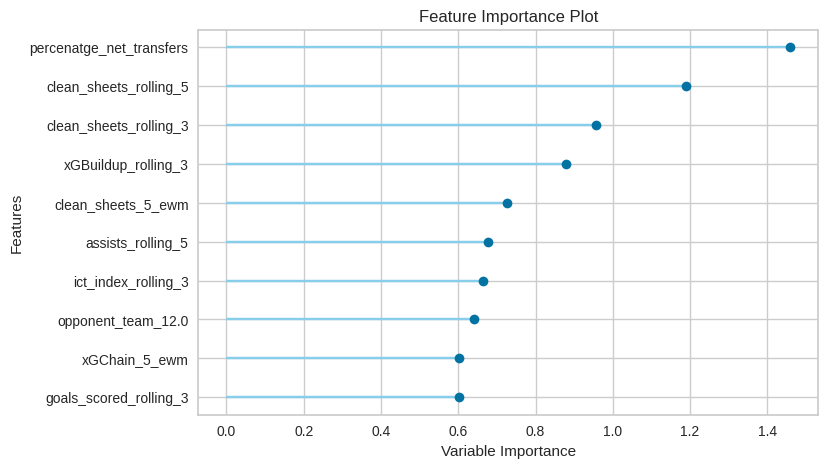

In [5]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 11)
base_model = setup(train_data, target = 'xP',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model = base_model.compare_models(sort='MAE', n_select=1)
print(best_model)

evaluate_model(best_model)

plot_model(best_model, plot='feature')        # Feature importance


## Feature Importance


In [6]:

def select_best_features(df, features):
    """
    Uses Recursive Feature Elimination (RFE) to rank features.
    """
    # Use data from a reliable point (e.g., after GW 7)
    # df = df[df['round'] < round]
    reliable_df = df[df['round'] >= 7].copy()

    X = reliable_df[features]
    y = reliable_df['xP']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Initialize Ridge and RFE
    estimator = Ridge(alpha=1.0)
    # We ask RFE to rank all features
    selector = RFE(estimator, n_features_to_select=1, step=1)
    selector = selector.fit(X_scaled, y)

    # Create ranking table
    ranking = pd.DataFrame({
        'Feature': features,
        'Rank': selector.ranking_,
        'Coefficient': estimator.fit(X_scaled, y).coef_
    }).sort_values('Rank')

    return ranking

def run_reliability_test(df, selected_features):
    """
    Simulates the season using only the selected features.
    """
    gws = sorted(df['round'].unique())
    results = []
    test_start_gw = 7
    scaler = StandardScaler()



    # for current_gw in range(test_start_gw, max(gws) + 1):
    train_df = df[df['round'] < round]
    test_df = df[df['round'] == round]

    X_train = scaler.fit_transform(train_df[selected_features])
    X_test = scaler.transform(test_df[selected_features])

    model = Ridge(alpha=1.0)
    model.fit(X_train, train_df['xP'])

    mae = mean_absolute_error(test_df['xP'], model.predict(X_test))
    results.append({'GW': round, 'MAE': mae})

    return pd.DataFrame(results)


In [7]:
# --- Execution --- [10, 15, 20]
def get_gw_best_features(round):
    print(f"Step 1: Ranking Features for GW {round} using Recursive Feature Elimination...")

    feature_ranks = select_best_features(data[data['round'] <= round],  feature_cols)

    # # Step 2: Automated Selection

    print(f"\nStep 2: Finding Optimal Feature Cut-off. of the {len(feature_cols)} features..")
    # We iterate through the top N features to find where MAE stops improving
    best_overall_mae = float('inf')
    optimal_count = 1
    mae_history = []

    # Testing up to top 10 (or however many you want to check)
    search_limit = min(len(feature_cols), 50)

    for i in range(1, search_limit + 1):
        trial_features = feature_ranks.head(i)['Feature'].tolist()
        reliability_df = run_reliability_test(data[data['round']<= round], trial_features)
        avg_mae = reliability_df['MAE'].mean()
        mae_history.append(avg_mae)

        print(f"Testing top {i} features: Average MAE = {avg_mae:.4f}")

        if avg_mae < best_overall_mae:
            best_overall_mae = avg_mae
            optimal_count = i

    best_features = feature_ranks.head(optimal_count)['Feature'].tolist()
    print(f"\nOptimal number of features: {optimal_count}")
    print(f"Selected Features: {round}==> {best_features}")

    return best_features, optimal_count, best_overall_mae


In [8]:
selected_features = {}
for round in range(7,24):
    selected_features[round] = get_gw_best_features(round)


Step 1: Ranking Features for GW 7 using Recursive Feature Elimination...

Step 2: Finding Optimal Feature Cut-off. of the 340 features..
Testing top 1 features: Average MAE = 0.7180
Testing top 2 features: Average MAE = 0.7179
Testing top 3 features: Average MAE = 0.7299
Testing top 4 features: Average MAE = 0.7967
Testing top 5 features: Average MAE = 0.7642
Testing top 6 features: Average MAE = 0.7886
Testing top 7 features: Average MAE = 0.7897
Testing top 8 features: Average MAE = 0.7846
Testing top 9 features: Average MAE = 0.7968
Testing top 10 features: Average MAE = 0.7690
Testing top 11 features: Average MAE = 0.7863
Testing top 12 features: Average MAE = 0.7900
Testing top 13 features: Average MAE = 0.8248
Testing top 14 features: Average MAE = 0.8271
Testing top 15 features: Average MAE = 0.8018
Testing top 16 features: Average MAE = 0.8087
Testing top 17 features: Average MAE = 0.7937
Testing top 18 features: Average MAE = 0.7934
Testing top 19 features: Average MAE = 0.790

In [9]:
selections = pd.DataFrame(selected_features).T
selections.columns = ['best_features', 'optimal_count', 'best_overall_mae']
selections

,best_features,optimal_count,best_overall_mae
7,"[xP_rolling_1, xP_1_ewm]",2,0.717896
8,"[form_1_ewm, percenatge_net_transfers, value, ...",40,0.778732
9,"[selected_by_percent, selected, xP_1_ewm]",3,0.699777
10,"[selected_by_percent, selected, selected_by_pe...",45,0.770091
11,"[selected_by_percent, selected, xP_1_ewm, perc...",41,0.851051
12,"[xP_1_ewm, pts_bonus_3_ewm, pts_bonus_1_ewm, p...",50,0.8755
13,"[selected_by_percent, selected, xP_1_ewm, pts_...",34,0.703405
14,"[xP_rolling_1, pts_bonus_3_ewm, pts_bonus_1_ew...",24,0.672828
15,"[xP_1_ewm, pts_bonus_3_ewm, pts_bonus_1_ewm, f...",6,0.743
16,"[selected_by_percent, selected, xP_1_ewm]",3,0.629917


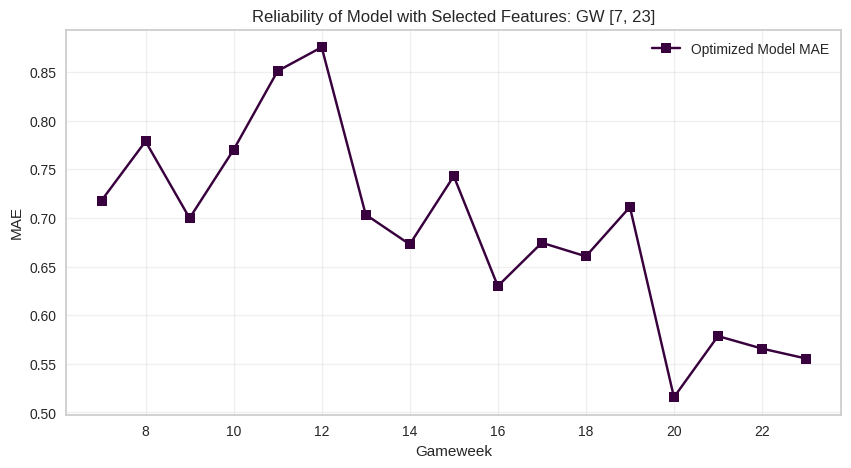

In [10]:

# --- Visualization ---
plt.figure(figsize=(10, 5))
plt.plot(selections.index, selections['best_overall_mae'], marker='s', color="#38003c", label='Optimized Model MAE')
plt.title('Reliability of Model with Selected Features: GW [7, 23]', fontsize=12)
plt.xlabel('Gameweek')
plt.ylabel('MAE')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
